# Semi-Supervised Folded-Spectrum Solution of the Kitaev-Chain Spectral Problem

## I. Introduction

This notebook is the label-anchored model at the top of the project's
four-model study of the 1D Kitaev chain. A single-head sinusoidal network
(SIREN) maps the chemical potential $\mu$ to a Nambu-basis
Bogoliubov--de Gennes (BdG) eigenvector; the energy is read off as the
Rayleigh quotient $E_R = \psi^{\mathsf T} H(\mu)\,\psi$. A small set of
exact eigenpairs from `numpy.linalg.eigh` anchors $E_R$ and the global sign
of $\psi$; a label-free folded-spectrum residual over a large collocation
batch does the rest, under a single physics-weight anneal.

It replaces the earlier **dual-head** model, which used a separate softplus
energy head and a deeper backbone; that attempt is kept as a record in
`dual-head-experiement.ipynb` and is not part of the comparative study. The
architecture here -- one $\ell_2$-normalised $\psi$ head, energy as a
Rayleigh quotient, no fold -- is **identical to the Nambu baseline**
(`nambu-fsm-baseline.ipynb`); only the loss differs. The collocation domain
$-4t < \mu < 4t$, the two-stage optimiser, and the evaluation probe are
shared with the other three notebooks, so all four produce a directly
comparable table.

## II. Formalism

### A. BdG Hamiltonian and the particle--hole operator

In the Nambu basis
$\Psi = (c_1,\dots,c_N,c_1^\dagger,\dots,c_N^\dagger)^{\mathsf T}$ the BdG
Hamiltonian of the open Kitaev chain is a real symmetric $2N \times 2N$
matrix, affine in $\mu$,

$$
H(\mu) \;=\; H_{\mathrm{base}} \;+\; \mu\, H_{\mu\text{-diag}}
\;=\;
\begin{pmatrix} A(\mu) & B \\[2pt] B^{\mathsf T} & -A(\mu) \end{pmatrix},
\tag{1}
$$

with $A(\mu)$ carrying the on-site potential and the hopping and $B$ the
$p$-wave pairing. The representation makes particle--hole conjugation
manifest, $\Xi\,H(\mu)\,\Xi = -H(\mu)$ with
$\Xi = \tau_x \otimes \mathbb{1}_N$ orthogonal. In a residual formulation
this symmetry carries no independent information: since $\Xi H \Xi = -H$,
the penalty $\lVert H(\Xi\psi) + E_R(\Xi\psi) \rVert^2$ equals
$\lVert H\psi - E_R\psi \rVert^2$ term by term, so a particle--hole loss
would be numerically identical to the eigenvector-consistency term and is
omitted here.

### B. Spectral target and the near-zero degeneracy

The target is the lowest non-negative eigenvalue $E(\mu)$ of $H(\mu)$ and
its eigenvector $\psi(\mu) = (u, w)$ (particle block $u$, hole block $w$).
Throughout the topological phase $|\mu| < 2t$ this is a near-zero mode
exponentially localised at the two ends of the chain; in the trivial phase
$|\mu| > 2t$ it rises as $E \to |\mu| - 2t$ and delocalises.

Deep in the topological phase the pair $\pm\lambda_1$ is degenerate to
$\lambda_1 \approx 2\times10^{-5}$ (the next gap is of order $t$), and
`numpy.linalg.eigh` returns an arbitrary rotation within the corresponding
two-dimensional near-zero eigenspace. Overlap with a single such vector is
ill-defined; eigenvector accuracy is measured instead as
$\lVert P_M\,\psi_{\mathrm{pred}} \rVert$, the norm of the projection onto
that 2-D span (Sec. VII C).

### C. Exact labels and gauge fixing

`SupervisedKitaevDataset` produces labelled triples $(\mu, E, \psi)$ by
diagonalising $H(\mu)$ directly; each costs one diagonalisation, so the
labelled set is kept small. An eigenvector from `eigh` is defined only up
to an overall sign; the dataset sorts the sampled $\mu$ ascending and flips
each eigenvector so that $\langle \psi(\mu_k), \psi(\mu_{k-1}) \rangle > 0$,
giving labels that vary smoothly with $\mu$. One global sign per connected
component of the sampled domain remains, resolved by the sign-aligned data
term of Sec. IV.

### D. Energy as a Rayleigh quotient, not a head

The energy is $E_R(\mu) = \psi_{\mathrm{pred}}(\mu)^{\mathsf T} H(\mu)\,
\psi_{\mathrm{pred}}(\mu)$, computed from the eigenvector rather than
produced by a dedicated network output. This is the energy mechanism of the
Nambu baseline and chiral models, so all four share it. It could instead be
a softplus head that forces $E \ge 0$ by construction (the dual-head
choice); the Rayleigh quotient is the more structural option, and
non-negativity is then a branch gauge -- fixed exactly on the labelled rows
by the energy label, and by sign-alignment to the reference at evaluation
elsewhere.

### E. What the labels fix, and what they do not

The energy label pins $E_R$ to the exact lowest non-negative eigenvalue on
the labelled rows, so the $+E$ branch is exact there. The $\psi$ label,
sign-aligned per row, breaks the **global** sign of $\psi$ -- enough to
select the trivial-phase branch. Neither label resolves the 2-D near-zero
manifold in the topological phase: that plane is under-determined by the
objective with or without supervision, exactly as for the label-free Nambu
models.

## III. Network architecture

The surrogate is a SIREN with a single linear head,
$\mu \longmapsto \psi_{\mathrm{pred}}(\mu) \in \mathbb{R}^{2N}$,
$\lVert \psi_{\mathrm{pred}} \rVert = 1$. Sinusoidal activations are used
because the physics residual differentiates the output with respect to
$\mu$. The **only** property enforced in the forward pass is the unit norm
of $\psi$ (`F.normalize` on the head output); the input is divided by
`input_scale = 4.0` to match the training domain $-4t < \mu < 4t$.

| property | this model | Nambu baseline |
|---|---|---|
| $\lVert \psi \rVert = 1$ | structural | structural |
| $E \ge 0$ | label on the $700$ rows, gauge elsewhere | soft (`loss_pin`) |
| per-$\mu$ topological eigenvector | global sign only | under-determined |
| $E(-\mu) = E(\mu)$ | learned | learned |

The backbone -- `hidden_features=64`, `hidden_layers=2`,
`hidden_omega_0=1.0` -- is exactly the Nambu baseline's. The two models
differ **only** in the loss of Sec. IV.

## IV. Loss functional

`SemiSupervisedFSMLoss` combines a small labelled batch with a large
label-free batch, concatenated so the labelled rows come first, and
minimises

$$
\mathcal{L} \;=\;
\mathcal{L}_e \;+\; \mathcal{L}_\psi
\;+\; w_{\mathrm{phys}}(\text{epoch}) \,
\big( \mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}} \big).
\tag{2}
$$

With $\mathbf{H}\psi \equiv H(\mu)\,\psi_{\mathrm{pred}}$ and
$E_R = \sum_i \psi_{\mathrm{pred},i}(\mathbf{H}\psi)_i$ the per-sample
Rayleigh quotient:

- $\mathcal{L}_e = \operatorname{MSE}(E_R^{1:n_\ell},\, E_{\mathrm{exact}})$
  on the labelled rows -- anchors the energy and, with it, the $+E$ branch
  there exactly (the job `loss_pin` does softly in the baseline).
- $\mathcal{L}_\psi = \operatorname{MSE}(\psi_{\mathrm{pred}}^{1:n_\ell},\,
  s \odot \psi_{\mathrm{exact}})$ with $s$ the detached per-row sign of
  $\langle \psi_{\mathrm{pred}}, \psi_{\mathrm{exact}} \rangle$. The
  alignment is required because $\mathcal{L}_{\mathrm{fsm}}$ and
  $\mathcal{L}_{\mathrm{var}}$ are invariant under $\psi \to -\psi$, so
  nothing else breaks the sign.
- $\mathcal{L}_{\mathrm{fsm}} = \langle \lVert \mathbf{H}\psi \rVert^2 \rangle$
  over all rows -- the folded-spectrum residual; its minimiser over the unit
  sphere is the eigenvector of the eigenvalue nearest zero.
- $\mathcal{L}_{\mathrm{var}} = \langle \lVert \mathbf{H}\psi - E_R \psi_{\mathrm{pred}} \rVert^2 \rangle$
  over all rows -- forces $\psi_{\mathrm{pred}}$ to be a genuine
  eigenvector, so $E_R$ is meaningful.

$w_{\mathrm{phys}}$ anneals $0.01 \to 1.0$ over the first
`anneal_duration` epochs -- the mirror image of the baseline's `w_pin`
schedule. Early on $\psi_{\mathrm{pred}}$ is close to random, so the
residual terms (computed from that prediction) are an unreliable signal
until the model has locked onto the labels. The ramp completes inside the
AdamW phase and `run_two_phase` continues the epoch count into the L-BFGS
phase, so $w_{\mathrm{phys}}$ stays at $1.0$ there rather than restarting.

| | dual-head `SemiSupervisedLoss` | this `SemiSupervisedFSMLoss` |
|---|---|---|
| energy | softplus head ($E \ge 0$ structural) | Rayleigh quotient (branch is a gauge) |
| physics terms | $\mathcal{L}_{\mathrm{res}} + \mathcal{L}_{\mathrm{PH}}$ | $\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ |
| $\mathcal{L}_{\mathrm{PH}}$ | carried ($\equiv \mathcal{L}_{\mathrm{res}}$) | dropped ($\equiv \mathcal{L}_{\mathrm{var}}$) |
| data terms | $\mathcal{L}_e,\ \mathcal{L}_\psi$ | $\mathcal{L}_e,\ \mathcal{L}_\psi$ (unchanged) |

## V. Label and collocation sampling

`MuSampler` draws from a weighted mixture of `SamplingRegion` intervals;
weights are relative, so a region's share is its own weight over the total.
`SEMI_SUPERVISED_REGIONS` matches the two-sided mixture the Nambu baseline
and structural notebooks use: a uniform full-domain slice, an oversampled
band either side of each transition at $\mu = \pm 2t$, and the trivial
phase out to $\pm 4t$ (weights sum to $5$).

The labelled set is $700$ training and $140$ validation triples (multiples
of the total weight, so every region contributes a whole number of
samples); the label-free pool is $8192$ $\mu$-only points. Two further
single-batch frozen pools -- the whole labelled set as one batch, and a
frozen $4096$-point label-free batch -- are built for the L-BFGS stage,
which needs a stationary objective.

## VI. Implementation

### A. Imports

The model, loss, sampling, training, and evaluation components used below
are provided by the `kitaev` package.

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data import SupervisedKitaevDataset, UnsupervisedMuGenerator
from kitaev.data.mu_sampler import MuSampler
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import RayleighEnergyAdapter, SirenPINN
from kitaev.training import BdGEvaluationProbe, TwoPhaseConfig, run_two_phase
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import SemiSupervisedFSMLoss
from kitaev.training.trainer import _build_kitaev_operators
from kitaev.visualisation import sweep_wavefunctions

### B. Session and device

A `Session` collects the run's log file and figure outputs; the
`Accelerator` selects the compute device.

In [2]:
session = Session(
    name="semi-supervised-fsm",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

### C. Hamiltonian

`_build_kitaev_operators` assembles the batched
$(H_{\mathrm{base}},\, H_{\mu\text{-diag}},\, \Xi)$ triple that
`SemiSupervisedFSMLoss` uses to form $H(\mu)$ for its residual terms. All
quantities are in units of $t$, with $N = 20$ and $\Delta = 0.5\,t$, so the
transition lies at $\mu = 2t$.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}, transition at |mu| = {2 * t}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

### D. Label and collocation sampling

The region mixture of Sec. V. The weights are relative and sum to $5$, so
the labelled sample counts below are multiples of $5$ and every region
contributes a whole number of points.

In [4]:
torch.manual_seed(42)

# Weights are relative: each region's share is its own weight over the total.
# This is the two-sided mixture the Nambu baseline / structural notebooks use.
SEMI_SUPERVISED_REGIONS = (
    SamplingRegion(low=-4.0, high=4.0, weight=1.0),  # full-domain slice
    SamplingRegion(low=-2.6, high=-1.7, weight=1.5),  # left transition band
    SamplingRegion(low=1.7, high=2.6, weight=1.5),  # right transition band
    SamplingRegion(low=-4.0, high=-2.0, weight=0.5),  # left trivial phase
    SamplingRegion(low=2.0, high=4.0, weight=0.5),  # right trivial phase
)  # weights sum to 5; the sample counts below are multiples of 5

### E. Datasets

$700$ labelled triples are diagonalised exactly for training and $140$ for
validation; the label-free stream is a pre-generated pool of $8192$ $\mu$
values with no diagonalisation. `train_loader` and `val_loader` yield
$(\mu, E, \psi)$ batches, `unlabeled_loader` yields $(\mu,)$ batches only,
and `UnifiedTrainer.fit` tells them apart by batch length alone.

The L-BFGS stage optimises a stationary objective, so it is given its own
single-batch pools: the whole labelled set as one $700$-row batch, and a
frozen $4096$-point label-free batch.

In [5]:
train_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=700,
    hamiltonian=hamiltonian,
)
train_loader = train_dataset.dataloader(batch_size=70, shuffle=True)

val_dataset = SupervisedKitaevDataset(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS),
    total_samples=140,
    hamiltonian=hamiltonian,
)
val_loader = val_dataset.dataloader(batch_size=140, shuffle=False)

unlabeled_loader = UnsupervisedMuGenerator(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS)
).dataloader(total_samples=8192, batch_size=256)

# Frozen single-batch pools for the L-BFGS stage: both the labelled and the
# label-free contributions must be the same batch every epoch, or the
# quasi-Newton curvature estimate is built on a moving target.
lbfgs_labeled_loader = train_dataset.dataloader(
    batch_size=len(train_dataset), shuffle=False
)
lbfgs_unlabeled_loader = UnsupervisedMuGenerator(
    sampler=MuSampler(SEMI_SUPERVISED_REGIONS)
).dataloader(total_samples=4096, batch_size=4096)

session.info(
    f"{len(train_dataset)} labelled training samples, "
    f"{len(val_dataset)} labelled validation samples, "
    "8192 label-free AdamW samples, 4096 frozen L-BFGS samples"
)

### F. Network, loss, optimisation schedule, and error probe

`SirenPINN` outputs the full $2N = 40$-component Nambu eigenvector, with
`input_scale = 4.0` for the widened domain -- the same backbone the Nambu
baseline uses. `SemiSupervisedFSMLoss`'s `anneal_duration = 1333`
($\lfloor E_{\mathrm{Adam}}/3 \rfloor$) keeps the $w_{\mathrm{phys}}$
ramp inside the AdamW phase.

`BdGEvaluationProbe` scores against exact diagonalisation on a fixed $\mu$
grid. `SirenPINN` returns only $\psi$, so it is bridged to the probe's
$(E, \psi)$ contract by `RayleighEnergyAdapter`, which attaches
$E_R = \psi^{\mathsf T} H(\mu)\,\psi$ (signed; the probe takes $|E_R|$).
The same probe and grid score the other three models.

In [6]:
model = SirenPINN(
    n_sites=2 * N,
    hidden_features=64,
    hidden_layers=2,
    input_scale=4.0,
)

# e + psi (labelled rows) + w_phys(epoch) * (fsm + var) (all rows).  w_phys
# ramps 0.01 -> 1.0 over anneal_duration, completing inside the AdamW phase so
# the model locks onto the exact labels before the physics residual reaches
# full strength.  No loss_ph: it is identically equal to loss_var here.
loss_fn = SemiSupervisedFSMLoss(total_epochs=4000, anneal_duration=4000 // 3)

# Stage 1: AdamW + cosine decay.  Stage 2: L-BFGS + strong-Wolfe line search
# on the frozen pools.  run_two_phase continues the epoch count into stage 2,
# so w_phys stays at 1.0 there.
TWO_PHASE = TwoPhaseConfig(
    adam_epochs=4000,
    adam_lr=8e-4,
    adam_weight_decay=1e-6,
    lbfgs_epochs=300,
    lbfgs_max_iter=25,
    lbfgs_history_size=20,
    lbfgs_line_search_fn="strong_wolfe",
)

# Final-epoch state is the one scored (restore_best=False, the default and the
# setting used for all four models): the w_phys anneal makes the pre-ramp
# epochs an artificial validation-loss minimum, so best-validation selection
# would roll back to a barely-physics-trained checkpoint.
two_phase_base = TrainerConfig(
    epochs=1, print_freq=300, patience=None, grad_clip_norm=1.0
)

probe = BdGEvaluationProbe(
    n_sites=N,
    hopping=t,
    pairing=delta,
    mu_grid=np.linspace(-4.0, 4.0, 240),
    every=50,
    session=session,
    adapt=lambda m: RayleighEnergyAdapter(m, n_sites=N, hopping=t, pairing=delta),
)

### G. Training

The loss (2) is minimised in two stages on a single network: $4000$ epochs
of AdamW under a cosine decay on the labelled and label-free batches, then
$300$ epochs of L-BFGS under a strong-Wolfe line search on the frozen
pools. `run_two_phase` returns the trained model and both stages'
histories concatenated; this combined history drives every figure of
Sec. VII.

This is a full experimental run: on a single GPU or Apple-silicon device
the AdamW stage takes a few minutes. Reduce `TWO_PHASE.adam_epochs` for a
quick pass.

In [7]:
trained_model, history = run_two_phase(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    two_phase=TWO_PHASE,
    base_config=two_phase_base,
    callbacks=[probe],  # error probe (AdamW stage)
    val_loader=val_loader,
    unlabeled_loader=unlabeled_loader,
    lbfgs_train_loader=lbfgs_labeled_loader,  # frozen labelled batch (L-BFGS)
    lbfgs_unlabeled_loader=lbfgs_unlabeled_loader,  # frozen label-free batch
    lbfgs_callbacks=[probe],  # keep the probe across both stages
)

adam_epochs = TWO_PHASE.adam_epochs
session.info(
    f"two-phase run complete: {len(history['train_loss'])} epochs recorded "
    f"({adam_epochs} AdamW + {TWO_PHASE.lbfgs_epochs} L-BFGS)"
)
session.info(
    f"train loss   AdamW end: {history['train_loss'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['train_loss'][-1]:.4e}"
)
session.info(
    f"val psi MSE  AdamW end: {history['val_psi'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['val_psi'][-1]:.4e}"
)
session.info(
    f"E MAE        first probe: {history['probe_e_mae'][0]:.4e}  "
    f"-> last probe: {history['probe_e_mae'][-1]:.4e}"
)

## VII. Results

The trained model is evaluated through `RayleighEnergyAdapter`, which
exposes $(|E_R|, \psi)$. All comparisons are against exact diagonalisation
of $H(\mu)$ on a uniform grid over $[-4t, 4t]$.

### Figure style

A common style is applied: the topological region $|\mu| < 2t$ is shaded
and both transitions at $\mu = \pm 2t$ are marked.

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK = "#1b2a41"
CORAL = "#e4572e"
TEAL = "#2a9d8f"
SLATE = "#8d99ae"
GOLD = "#e9c46a"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": SLATE,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#e6e8ec",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "600",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)


def _mark_topological(ax, t, mu_max):
    """Shade the topological phase |mu| < 2t and mark both transitions."""
    ax.axvspan(-2 * t, 2 * t, color=TEAL, alpha=0.07, lw=0)
    for x in (-2 * t, 2 * t):
        ax.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.1)
    ax.set_xlim(-mu_max, mu_max)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))


def _annotate_phases(ax, t, y):
    ax.text(
        0.0,
        y,
        "topological",
        ha="center",
        va="center",
        fontsize=9,
        color=TEAL,
        weight="600",
    )
    for x in (-3 * t, 3 * t):
        ax.text(
            x,
            y,
            "trivial",
            ha="center",
            va="center",
            fontsize=9,
            color=SLATE,
            weight="600",
        )

### A. Optimisation history and physical error

Figure 1 shows the total loss and its four components on a logarithmic
scale, with $w_{\mathrm{phys}}$ on the right axis and the AdamW $\to$
L-BFGS hand-over marked. The data terms $\mathcal{L}_e$ and
$\mathcal{L}_\psi$ fall first as the model fits the labels;
$\mathcal{L}_{\mathrm{fsm}}$ and $\mathcal{L}_{\mathrm{var}}$ fall once
$w_{\mathrm{phys}}$ has ramped in.

Figure 2 plots the `BdGEvaluationProbe` quantities against the cumulative
epoch index: energy MAE split into topological and trivial phases, the
combined edge-weight error, and the subspace infidelity
$1 - \lVert P_M\,\psi_{\mathrm{pred}} \rVert$. Once the data terms
converge the total loss changes little while the probe errors keep
falling -- the probe is the better guide to whether the model is still
improving.

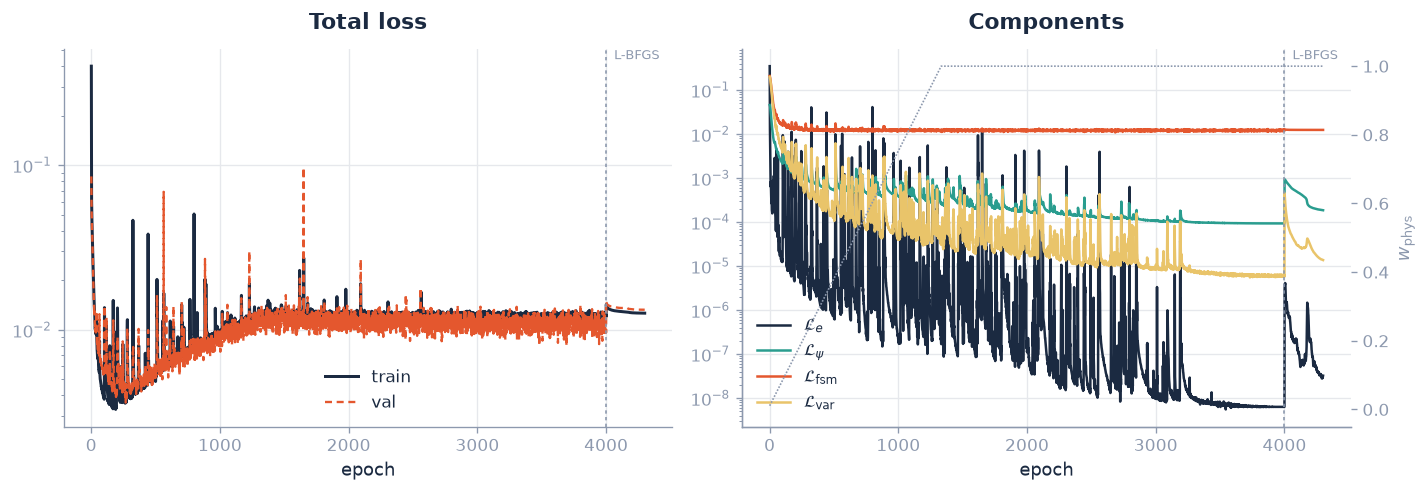

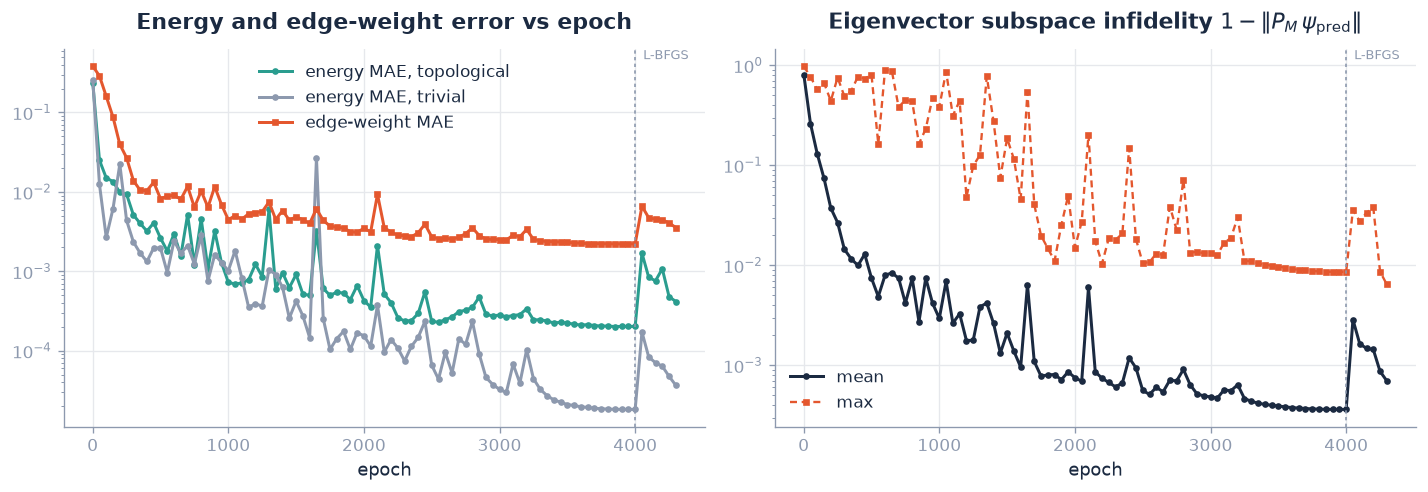

In [9]:
epochs = range(1, len(history["train_loss"]) + 1)
split = TWO_PHASE.adam_epochs  # AdamW -> L-BFGS hand-over


def _mark_phase_split(ax, top=True):
    ax.axvline(split, color=SLATE, ls=(0, (2, 2)), lw=1.0)
    ax.text(
        split,
        ax.get_ylim()[1] if top else ax.get_ylim()[0],
        "  L-BFGS",
        ha="left",
        va="top" if top else "bottom",
        fontsize=8,
        color=SLATE,
    )


# --- Figure 1: loss history and components ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, history["train_loss"], color=INK, lw=1.8, label="train")
if "val_loss" in history:
    axes[0].plot(
        epochs, history["val_loss"], color=CORAL, lw=1.4, ls=(0, (3, 2)), label="val"
    )
axes[0].set_yscale("log")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

for key, colour, label in (
    ("train_e", INK, r"$\mathcal{L}_e$"),
    ("train_psi", TEAL, r"$\mathcal{L}_\psi$"),
    ("train_fsm", CORAL, r"$\mathcal{L}_{\rm fsm}$"),
    ("train_var", GOLD, r"$\mathcal{L}_{\rm var}$"),
):
    axes[1].plot(epochs, history[key], color=colour, lw=1.5, label=label)
axes[1].set_yscale("log")
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend(loc="lower left")

wt = axes[1].twinx()
wt.plot(epochs, history["train_physics_wt"], color=SLATE, lw=1.0, ls=(0, (1, 1)))
wt.set_ylabel(r"$w_{\rm phys}$", color=SLATE)
wt.set_ylim(-0.05, 1.05)
wt.tick_params(axis="y", colors=SLATE)
wt.grid(False)

fig.tight_layout()
fig.savefig(session.path() / "loss_history.png", bbox_inches="tight")

# --- Figure 2: physical errors recorded by the probe ----------------------
p_epoch = np.asarray(history["probe_epoch"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    p_epoch,
    history["probe_e_mae_topological"],
    color=TEAL,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, topological",
)
axes[0].plot(
    p_epoch,
    history["probe_e_mae_trivial"],
    color=SLATE,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, trivial",
)
axes[0].plot(
    p_epoch,
    history["probe_edge_mae"],
    color=CORAL,
    lw=1.8,
    marker="s",
    ms=3,
    label="edge-weight MAE",
)
axes[0].set_yscale("log")
axes[0].set_title("Energy and edge-weight error vs epoch")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity"],
    color=INK,
    lw=1.8,
    marker="o",
    ms=3,
    label="mean",
)
axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity_max"],
    color=CORAL,
    lw=1.4,
    ls=(0, (3, 2)),
    marker="s",
    ms=3,
    label="max",
)
axes[1].set_yscale("log")
axes[1].set_title(r"Eigenvector subspace infidelity $1 - \|P_M\,\psi_{\rm pred}\|$")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "probe_history.png", bbox_inches="tight")

### B. Lowest eigenvalue

Figure 3 compares $|E_R(\mu)|$ with exact diagonalisation across
$\mu \in [-4t, 4t]$ -- the near-zero mode throughout $|\mu| < 2t$ and the
linear approach $E \to |\mu| - 2t$ beyond. The inset shows the absolute
error on a logarithmic scale; the per-phase MAE is in the log output.

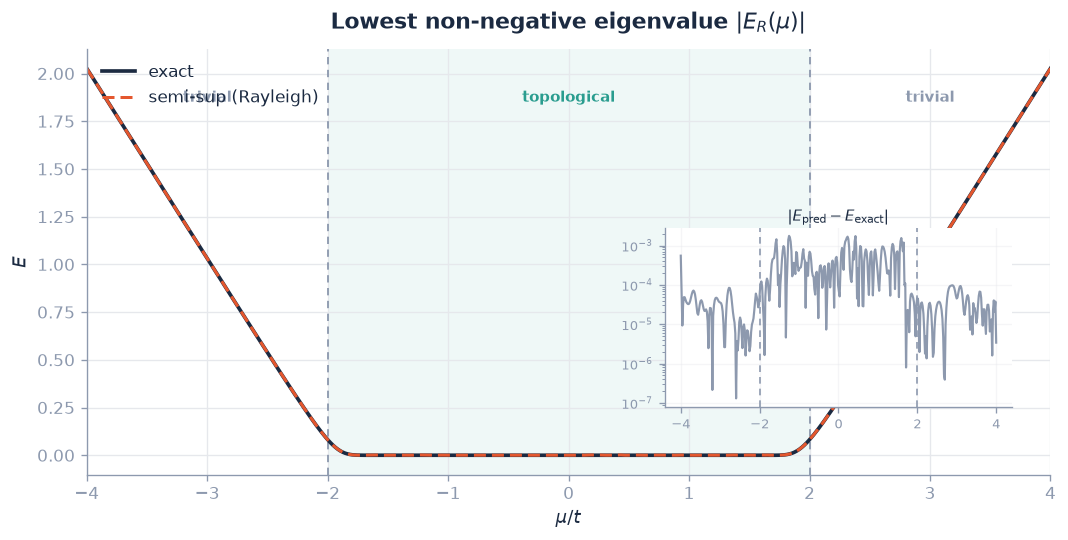

In [10]:
adapter = RayleighEnergyAdapter(trained_model, n_sites=N, hopping=t, pairing=delta).to(
    accelerator.device
)
adapter.eval()

mu_sweep = np.linspace(-4.0, 4.0, 400)
with torch.no_grad():
    mu_tensor = torch.tensor(
        mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_pred_t, psi_pred_t = adapter(mu_tensor)
e_pred = np.abs(e_pred_t.cpu().numpy().ravel())  # |E_R|: branch is a gauge here
psi_pred = psi_pred_t.cpu().numpy()

e_exact = np.array(
    [np.linalg.eigvalsh(hamiltonian.build(float(m)))[N] for m in mu_sweep]
)
abs_err = np.abs(e_pred - e_exact)
topo = np.abs(mu_sweep) < 2 * t

fig, ax = plt.subplots(figsize=(9, 4.6))
_mark_topological(ax, t, 4.0)
ax.plot(mu_sweep, e_exact, color=INK, lw=2.2, label="exact")
ax.plot(
    mu_sweep, e_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="semi-sup (Rayleigh)"
)
ax.fill_between(mu_sweep, e_exact, e_pred, color=CORAL, alpha=0.12, lw=0)
ax.set_title(r"Lowest non-negative eigenvalue $|E_R(\mu)|$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
_annotate_phases(ax, t, y=ax.get_ylim()[1] * 0.88)
ax.legend(loc="upper left")

inset = ax.inset_axes([0.60, 0.16, 0.36, 0.42])
inset.plot(mu_sweep, abs_err, color=SLATE, lw=1.3)
for x in (-2 * t, 2 * t):
    inset.axvline(x, color=SLATE, ls=(0, (4, 3)), lw=1.0)
inset.set_yscale("log")
inset.set_title(r"$|E_{\rm pred} - E_{\rm exact}|$", fontsize=9, pad=4)
inset.tick_params(labelsize=8)
inset.grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(session.path() / "energy_sweep.png", bbox_inches="tight")

session.info(f"|E_R(mu)| MAE over [-4t, 4t]:    {abs_err.mean():.4e}")
session.info(f"E MAE, topological (|mu| < 2t): {abs_err[topo].mean():.4e}")
session.info(f"E MAE, trivial     (|mu| > 2t): {abs_err[~topo].mean():.4e}")

### C. Eigenvector fidelity and edge localisation

The left panel of Fig. 4 reports $\lVert P_M\,\psi_{\mathrm{pred}} \rVert$,
the projection onto the span of the two exact eigenvectors of smallest
$|E|$ -- the well-defined accuracy measure where the $\pm\lambda_1$ pair
is degenerate. The right panel shows the combined particle and hole weight
on the two outermost sites at each end.

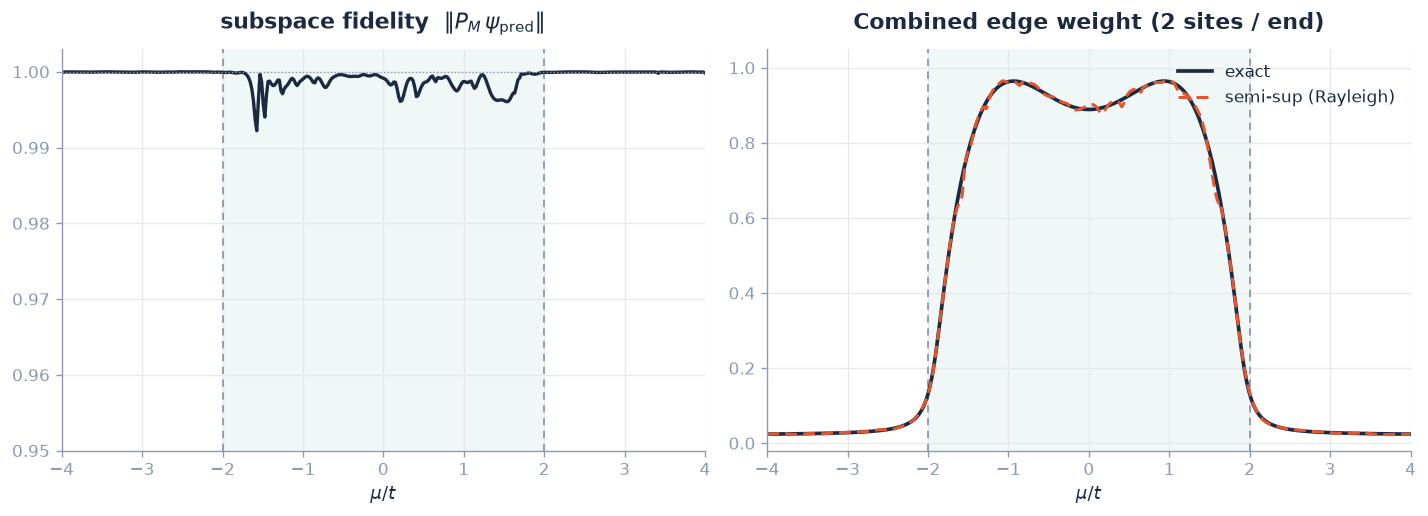

In [11]:
n_edge = 2
edge_idx = np.r_[0:n_edge, N - n_edge : N]

subspace_fidelity = np.empty_like(mu_sweep)
edge_exact = np.empty_like(mu_sweep)
for i, m in enumerate(mu_sweep):
    w, V = np.linalg.eigh(hamiltonian.build(float(m)))
    near_zero = V[:, np.argsort(np.abs(w))[:2]]  # the +/- lambda_min pair
    subspace_fidelity[i] = np.linalg.norm(near_zero.T @ psi_pred[i])
    psi_e = V[:, N]
    edge_exact[i] = (psi_e[:N][edge_idx] ** 2).sum() + (psi_e[N:][edge_idx] ** 2).sum()

prob_pred = psi_pred**2
edge_pred = prob_pred[:, :N][:, edge_idx].sum(1) + prob_pred[:, N:][:, edge_idx].sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

_mark_topological(axes[0], t, 4.0)
axes[0].plot(mu_sweep, subspace_fidelity, color=INK, lw=2.0)
axes[0].set_ylim(min(0.95, subspace_fidelity.min() - 0.01), 1.003)
axes[0].axhline(1.0, color=SLATE, lw=0.8, ls=":")
axes[0].set_title(r"subspace fidelity  $\|P_M\,\psi_{\rm pred}\|$")
axes[0].set_xlabel(r"$\mu / t$")

_mark_topological(axes[1], t, 4.0)
axes[1].plot(mu_sweep, edge_exact, color=INK, lw=2.2, label="exact")
axes[1].plot(
    mu_sweep,
    edge_pred,
    color=CORAL,
    lw=1.8,
    ls=(0, (4, 2)),
    label="semi-sup (Rayleigh)",
)
axes[1].set_title("Combined edge weight (2 sites / end)")
axes[1].set_xlabel(r"$\mu / t$")
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(session.path() / "eigenvector_agreement.png", bbox_inches="tight")

session.info(
    f"mean subspace fidelity: {subspace_fidelity.mean():.4f}  "
    f"(min {subspace_fidelity.min():.4f})"
)
session.info(f"edge-weight MAE: {np.abs(edge_pred - edge_exact).mean():.4e}")

### D. Probability densities

Figure 5 shows the particle- and hole-sector densities $|\psi_n|^2$ at
$\mu = \pm 3.4\,t$ (deep trivial), $\pm 1.0\,t$ (topological), and $0$,
sign-aligned to `eigh`.

The trivial-phase columns are a genuine test and agree closely -- the
global $\psi$ sign is fixed by $\mathcal{L}_\psi$ there. **The topological
columns are not a well-posed per-site comparison:** throughout
$|\mu| \lesssim 1.5\,t$ the $\pm\lambda_1$ pair is degenerate to
$\lambda_1 \approx 2\times10^{-5}$, so
$\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$ is flat over the
entire 2-D near-zero plane and the $\psi$ label -- which fixes only the
global sign -- does not select a rotation within it. The prediction stays
in the correct subspace (Fig. 4, left) but on an arbitrary section, and
with no $\mu \to -\mu$ fold the two halves are optimised independently, so
the section can differ between $+\mu$ and $-\mu$ -- the same caveat as the
Nambu baseline and structural notebooks.

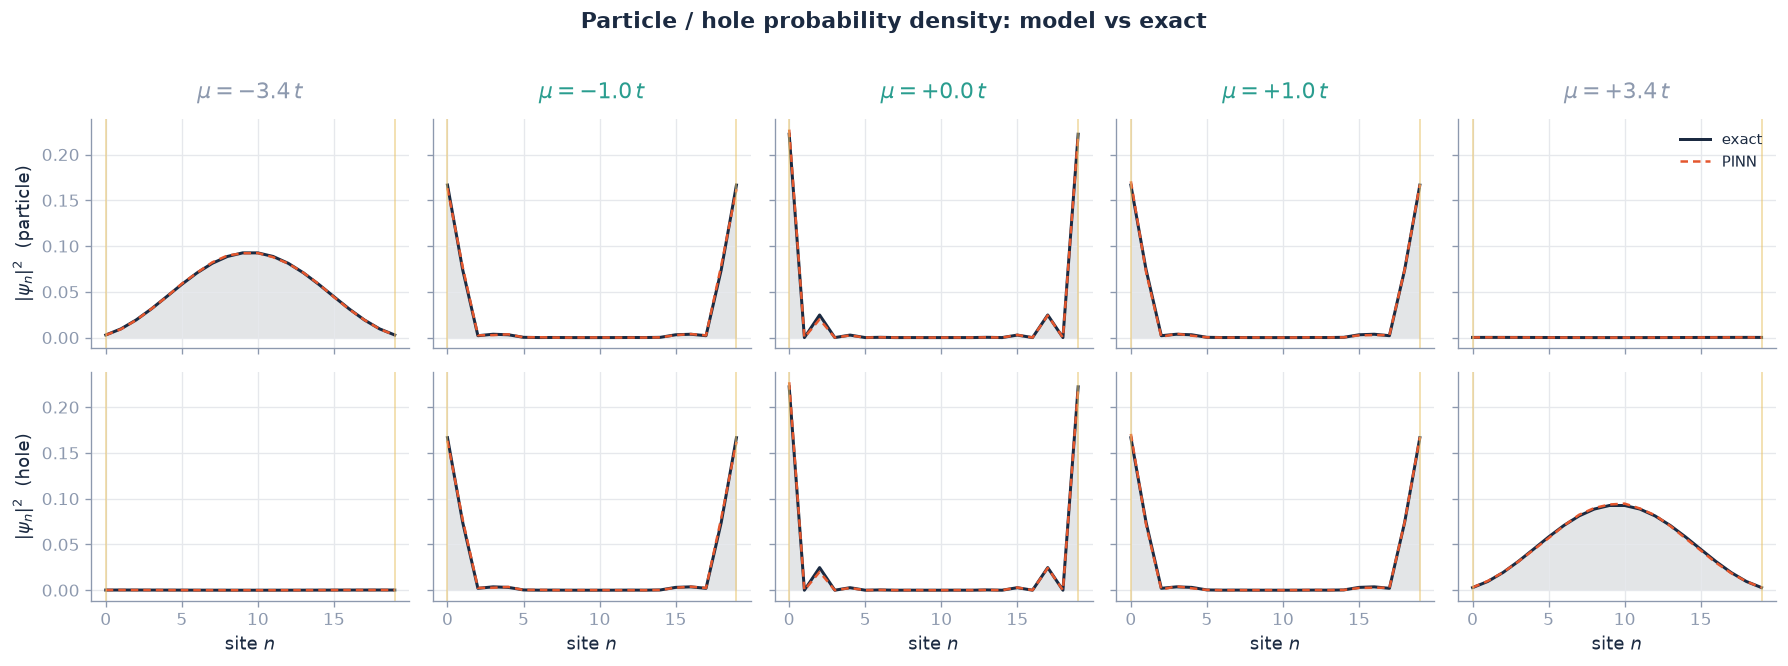

In [12]:
probe_mus = [-3.4, -1.0, 0.0, 1.0, 3.4]
wf = sweep_wavefunctions(adapter, hamiltonian, probe_mus, device=accelerator.device)

fig, axes = plt.subplots(
    2, len(probe_mus), figsize=(3.0 * len(probe_mus), 5.4), sharex=True, sharey="row"
)
sites = wf.sites

for col, mu in enumerate(probe_mus):
    topo_col = abs(mu) < 2 * t
    tag_color = TEAL if topo_col else SLATE
    for row, (exact, pred, label) in enumerate(
        (
            (wf.particle_exact[col], wf.particle_pred[col], "particle"),
            (wf.hole_exact[col], wf.hole_pred[col], "hole"),
        )
    ):
        ax = axes[row, col]
        ax.fill_between(sites, exact, color=INK, alpha=0.12, lw=0)
        ax.plot(sites, exact, color=INK, lw=1.8, label="exact")
        ax.plot(sites, pred, color=CORAL, lw=1.5, ls=(0, (3, 2)), label="PINN")
        for edge in (0, N - 1):
            ax.axvline(edge, color=GOLD, lw=1.0, alpha=0.6)
        if row == 0:
            ax.set_title(rf"$\mu = {mu:+.1f}\,t$", color=tag_color)
        if col == 0:
            ax.set_ylabel(rf"$|\psi_n|^2$  ({label})")
        if row == 1:
            ax.set_xlabel("site $n$")

axes[0, -1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Particle / hole probability density: model vs exact",
    y=1.02,
    fontsize=13,
    weight="600",
)
fig.tight_layout()
fig.savefig(session.path() / "wavefunctions.png", bbox_inches="tight")

### E. Reflection symmetry -- learned, not structural

`SirenPINN` has no $\mu \to -\mu$ fold, so $E(-\mu) = E(\mu)$ is a
property the network learns from the two-sided sampling rather than one it
is given. Figure 6 overlays $|E_R(\mu)|$ and $|E_R(-\mu)|$ over $[0, 4t]$;
the residual $\max_\mu |E_R(-\mu) - E_R(\mu)|$ is in the log output. A
nonzero residual is expected -- in contrast to the structural Nambu
notebook, where the fold makes it exact.

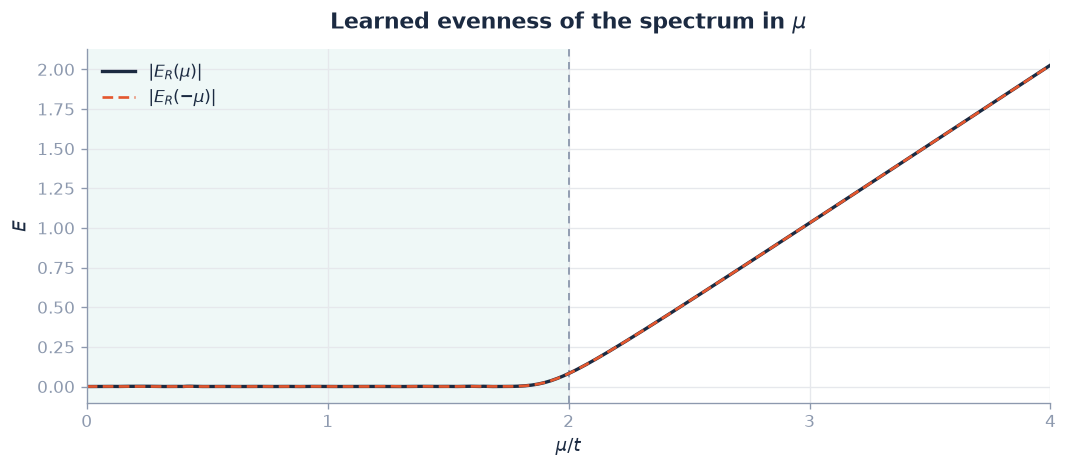

In [13]:
half = np.linspace(0.0, 4.0, 300)
with torch.no_grad():
    pos = torch.tensor(half[:, None], dtype=torch.float32, device=accelerator.device)
    e_pos = np.abs(adapter(pos)[0].cpu().numpy().ravel())
    e_neg = np.abs(adapter(-pos)[0].cpu().numpy().ravel())

fig, ax = plt.subplots(figsize=(9, 4.0))
_mark_topological(ax, t, 4.0)
ax.set_xlim(0, 4.0)
ax.plot(half, e_pos, color=INK, lw=2.0, label=r"$|E_R(\mu)|$")
ax.plot(half, e_neg, color=CORAL, lw=1.6, ls=(0, (4, 2)), label=r"$|E_R(-\mu)|$")
ax.set_title(r"Learned evenness of the spectrum in $\mu$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(session.path() / "mu_reflection.png", bbox_inches="tight")

session.info(f"max |E_R(-mu) - E_R(mu)| (learned): {np.abs(e_neg - e_pos).max():.3e}")

## VIII. Summary

The single-head SIREN enforces only $\lVert \psi \rVert = 1$. A small
exactly-diagonalised anchor set fixes the Rayleigh-quotient energy and the
global $\psi$ sign; a label-free folded-spectrum residual
($\mathcal{L}_{\mathrm{fsm}} + \mathcal{L}_{\mathrm{var}}$) over the large
collocation batch does the rest, under one physics-weight anneal. There is
no energy head and no particle--hole term (it is identically
$\mathcal{L}_{\mathrm{var}}$ in this basis). The architecture is the Nambu
baseline's; only the loss differs.

Trained in two stages over $-4t < \mu < 4t$ (AdamW while $w_{\mathrm{phys}}$
ramps in, then L-BFGS on frozen single-batch labelled and label-free
pools, with the epoch count continued so the anneal does not restart), the
model is accurate on every gauge-invariant quantity: the lowest eigenvalue
(Fig. 3), the combined edge weight (Fig. 4, right), the subspace fidelity
(Fig. 4, left), and the learned evenness in $\mu$ (Fig. 6). The probe
curves (Fig. 2) show these errors falling through the plateau of the total
loss.

What the labels buy: an exact $+E$ branch on the anchor rows, and the
trivial-phase $\psi$ sign. What they do not buy: the per-$\mu$ topological
eigenvector, which is under-determined in the Nambu basis with or without
supervision -- visible in Fig. 5 as the arbitrary rotation within the
degenerate plane. Removing the labels (`nambu-fsm-baseline.ipynb`) costs
only that trivial-phase sign; the structural Nambu notebook then asks
whether the eigenvector failure is a loss-design problem (it is not), and
the chiral notebook fixes it by changing the representation. This run is
their label-anchored reference point.